# IR ALEM 2 - Inteligencia Artificial em series temporais de saude

Este notebook compara modelos tradicionais de classificacao, baseados em atributos estatisticos extraidos da serie temporal, com uma abordagem neuromorfica simples usando neuronios LIF (*Leaky Integrate-and-Fire*).

O sinal vital usado e uma serie temporal sintetica de batimentos cardiacos, representando tres classes: normal, taquicardia e irregular.


In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import perf_counter

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
plt.style.use('seaborn-v0_8-whitegrid')


## 1. Geracao da base sintetica

Em um projeto real, esta etapa seria substituida por uma base clinica validada. Aqui a simulacao permite manter o notebook reprodutivel e focar na comparacao dos modelos.

In [3]:
def simulate_heart_rate_dataset(n_samples=900, window_size=180, seed=42):
    """Gera janelas sinteticas de batimentos cardiacos em bpm."""
    rng = np.random.default_rng(seed)
    classes = np.array(['normal', 'taquicardia', 'irregular'])
    signals = []
    labels = []
    t = np.linspace(0, 1, window_size)

    for i in range(n_samples):
        label = classes[i % len(classes)]

        if label == 'normal':
            baseline = rng.normal(72, 4)
            amplitude = rng.uniform(2, 5)
            noise = rng.normal(0, 1.8, window_size)
            signal = baseline + amplitude * np.sin(2 * np.pi * rng.uniform(2, 4) * t) + noise
        elif label == 'taquicardia':
            baseline = rng.normal(118, 7)
            trend = rng.normal(8, 3) * t
            noise = rng.normal(0, 2.4, window_size)
            signal = baseline + trend + 3 * np.sin(2 * np.pi * rng.uniform(3, 6) * t) + noise
        else:
            baseline = rng.normal(83, 6)
            noise = rng.normal(0, 4.2, window_size)
            jumps = rng.choice([0, 1], size=window_size, p=[0.91, 0.09]) * rng.normal(0, 18, window_size)
            signal = baseline + 4 * np.sin(2 * np.pi * rng.uniform(1, 5) * t) + noise + jumps

        signals.append(np.clip(signal, 45, 170))
        labels.append(label)

    return np.array(signals), np.array(labels)

X_raw, y = simulate_heart_rate_dataset()
print(X_raw.shape, y.shape)
pd.Series(y).value_counts()

(900, 180) (900,)


normal         300
taquicardia    300
irregular      300
Name: count, dtype: int64

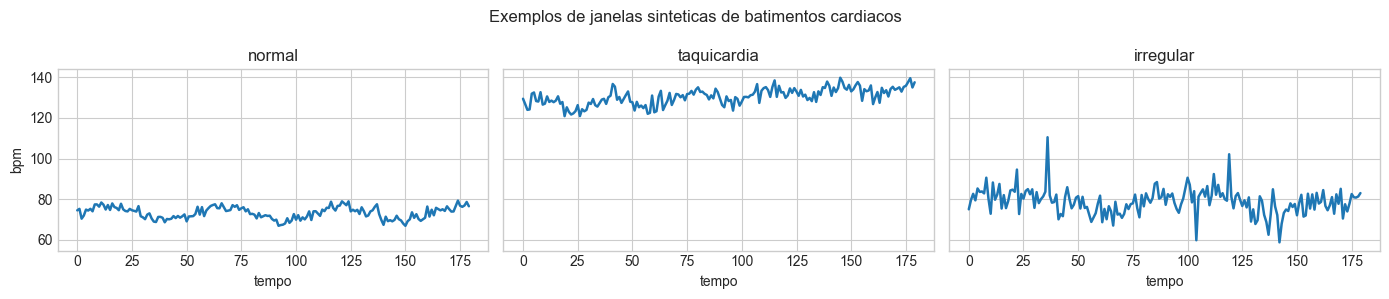

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3), sharey=True)
for ax, label in zip(axes, ['normal', 'taquicardia', 'irregular']):
    idx = np.where(y == label)[0][0]
    ax.plot(X_raw[idx], linewidth=1.8)
    ax.set_title(label)
    ax.set_xlabel('tempo')
axes[0].set_ylabel('bpm')
plt.suptitle('Exemplos de janelas sinteticas de batimentos cardiacos')
plt.tight_layout()
plt.show()

## 2. Modelos tradicionais: atributos + classificadores

Os modelos tradicionais recebem atributos resumidos da janela temporal. A ideia e comparar varias linhas de base interpretaveis ou consolidadas, evitando depender apenas da regressao logistica.


In [5]:
def extract_statistical_features(signals):
    """Extrai atributos estatisticos e temporais simples de cada janela."""
    rows = []
    for x in signals:
        diff = np.diff(x)
        centered = x - x.mean()
        spectrum = np.abs(np.fft.rfft(centered)) ** 2
        low_energy = spectrum[1:6].sum()
        high_energy = spectrum[6:20].sum()
        autocorr_1 = np.corrcoef(x[:-1], x[1:])[0, 1]

        rows.append({
            'media': x.mean(),
            'desvio_padrao': x.std(),
            'minimo': x.min(),
            'maximo': x.max(),
            'amplitude': x.max() - x.min(),
            'rmssd': np.sqrt(np.mean(diff ** 2)),
            'inclinacao': np.polyfit(np.arange(len(x)), x, 1)[0],
            'pnn20': np.mean(np.abs(diff) > 20),
            'autocorr_lag1': 0 if np.isnan(autocorr_1) else autocorr_1,
            'energia_baixa': low_energy,
            'energia_alta': high_energy,
            'razao_energia': high_energy / (low_energy + 1e-9),
        })
    return pd.DataFrame(rows)

X_features = extract_statistical_features(X_raw)
X_features = X_features.replace([np.inf, -np.inf], np.nan).fillna(0)
X_train_raw, X_test_raw, X_train_features, X_test_features, y_train, y_test = train_test_split(
    X_raw, X_features, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

traditional_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
)
traditional_model.fit(X_train_features, y_train)
traditional_pred = traditional_model.predict(X_test_features)

print(classification_report(y_test, traditional_pred))

              precision    recall  f1-score   support

   irregular       1.00      1.00      1.00        75
      normal       1.00      1.00      1.00        75
 taquicardia       1.00      1.00      1.00        75

    accuracy                           1.00       225
   macro avg       1.00      1.00      1.00       225
weighted avg       1.00      1.00      1.00       225



### 2.1 Modelo SVM (Support Vector Machine)

In [6]:
from sklearn.svm import SVC

svm_model = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', random_state=RANDOM_STATE)
)
svm_model.fit(X_train_features, y_train)
svm_pred = svm_model.predict(X_test_features)

print("SVM Classification Report:")
print(classification_report(y_test, svm_pred))

SVM Classification Report:
              precision    recall  f1-score   support

   irregular       1.00      1.00      1.00        75
      normal       1.00      1.00      1.00        75
 taquicardia       1.00      1.00      1.00        75

    accuracy                           1.00       225
   macro avg       1.00      1.00      1.00       225
weighted avg       1.00      1.00      1.00       225



### 2.2 Modelo Random Forest

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_model = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
)
rf_model.fit(X_train_features, y_train)
rf_pred = rf_model.predict(X_test_features)

print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

   irregular       1.00      1.00      1.00        75
      normal       1.00      1.00      1.00        75
 taquicardia       1.00      1.00      1.00        75

    accuracy                           1.00       225
   macro avg       1.00      1.00      1.00       225
weighted avg       1.00      1.00      1.00       225



### 2.3 Modelo K-Nearest Neighbors (KNN)

In [8]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=5)
)
knn_model.fit(X_train_features, y_train)
knn_pred = knn_model.predict(X_test_features)

print("KNN Classification Report:")
print(classification_report(y_test, knn_pred))

KNN Classification Report:
              precision    recall  f1-score   support

   irregular       1.00      1.00      1.00        75
      normal       1.00      1.00      1.00        75
 taquicardia       1.00      1.00      1.00        75

    accuracy                           1.00       225
   macro avg       1.00      1.00      1.00       225
weighted avg       1.00      1.00      1.00       225



### 2.4 Modelo Arvore de Decisao


In [9]:
from sklearn.tree import DecisionTreeClassifier

dt_model = make_pipeline(
    StandardScaler(),
    DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
)
dt_model.fit(X_train_features, y_train)
dt_pred = dt_model.predict(X_test_features)

print("Arvore de Decisao Classification Report:")
print(classification_report(y_test, dt_pred))


Arvore de Decisao Classification Report:
              precision    recall  f1-score   support

   irregular       1.00      1.00      1.00        75
      normal       1.00      1.00      1.00        75
 taquicardia       1.00      1.00      1.00        75

    accuracy                           1.00       225
   macro avg       1.00      1.00      1.00       225
weighted avg       1.00      1.00      1.00       225



### 2.5 Modelo Gradient Boosting


In [10]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = make_pipeline(
    StandardScaler(),
    GradientBoostingClassifier(random_state=RANDOM_STATE)
)
gb_model.fit(X_train_features, y_train)
gb_pred = gb_model.predict(X_test_features)

print("Gradient Boosting Classification Report:")
print(classification_report(y_test, gb_pred))


Gradient Boosting Classification Report:
              precision    recall  f1-score   support

   irregular       1.00      1.00      1.00        75
      normal       1.00      1.00      1.00        75
 taquicardia       1.00      1.00      1.00        75

    accuracy                           1.00       225
   macro avg       1.00      1.00      1.00       225
weighted avg       1.00      1.00      1.00       225



### 2.6 Modelo Naive Bayes Gaussiano


In [11]:
from sklearn.naive_bayes import GaussianNB

gnb_model = make_pipeline(
    StandardScaler(),
    GaussianNB()
)
gnb_model.fit(X_train_features, y_train)
gnb_pred = gnb_model.predict(X_test_features)

print("Naive Bayes Gaussiano Classification Report:")
print(classification_report(y_test, gnb_pred))


Naive Bayes Gaussiano Classification Report:
              precision    recall  f1-score   support

   irregular       1.00      1.00      1.00        75
      normal       1.00      1.00      1.00        75
 taquicardia       1.00      1.00      1.00        75

    accuracy                           1.00       225
   macro avg       1.00      1.00      1.00       225
weighted avg       1.00      1.00      1.00       225



## 3. Modelo neuromorfico: LIF e variacoes

O modelo LIF transforma a serie em disparos. Cada neuronio possui ganho e limiar diferentes, criando uma pequena populacao sensivel a padroes variados do sinal.

A primeira versao abaixo e a linha de base neuromorfica simples. Em seguida, sao testadas variacoes para reduzir fragilidades do LIF inicial e aumentar a capacidade de representar dinamicas temporais.


In [12]:
def lif_encode(signals, n_neurons=24, tau=14.0, resistance=1.0, seed=42):
    """Codifica series temporais em caracteristicas de disparo de neuronios LIF."""
    rng = np.random.default_rng(seed)
    gains = rng.uniform(0.85, 1.35, n_neurons)
    thresholds = rng.uniform(0.55, 1.05, n_neurons)
    features = []

    global_min = signals.min()
    global_max = signals.max()
    normalized = (signals - global_min) / (global_max - global_min + 1e-9)

    for signal in normalized:
        neuron_features = []
        for gain, threshold in zip(gains, thresholds):
            v = 0.0
            spike_times = []
            for step, current in enumerate(signal * gain):
                # A membrana acumula corrente, perde carga com o tempo e dispara ao cruzar o limiar.
                dv = (-v + resistance * current) / tau
                v += dv
                if v >= threshold:
                    spike_times.append(step)
                    v = 0.0

            spike_times = np.array(spike_times)
            rate = len(spike_times) / len(signal)
            first_spike = spike_times[0] / len(signal) if len(spike_times) else 1.0
            isi_std = np.std(np.diff(spike_times)) if len(spike_times) > 2 else 0.0
            neuron_features.extend([rate, first_spike, isi_std])
        features.append(neuron_features)

    return np.array(features)

X_lif_train = lif_encode(X_train_raw, seed=RANDOM_STATE)
X_lif_test = lif_encode(X_test_raw, seed=RANDOM_STATE)
X_lif_train = np.nan_to_num(X_lif_train, nan=0.0, posinf=0.0, neginf=0.0)
X_lif_test = np.nan_to_num(X_lif_test, nan=0.0, posinf=0.0, neginf=0.0)

lif_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
)
lif_model.fit(X_lif_train, y_train)
lif_pred = lif_model.predict(X_lif_test)

print(classification_report(y_test, lif_pred))

              precision    recall  f1-score   support

   irregular       0.00      0.00      0.00        75
      normal       0.50      1.00      0.67        75
 taquicardia       1.00      0.99      0.99        75

    accuracy                           0.66       225
   macro avg       0.50      0.66      0.55       225
weighted avg       0.50      0.66      0.55       225



### 3.1 LIF melhorado: normalizacao pelo treino e atributos de disparo

A versao inicial normaliza o conjunto recebido internamente. Aqui a escala passa a ser definida apenas pelo treino e reutilizada no teste. Tambem sao extraidos mais atributos por neuronio, como ultimo disparo, media dos intervalos e potencial final da membrana.


In [13]:
def lif_encode_rich(signals, n_neurons=32, tau=12.0, resistance=1.0, data_min=None, data_max=None, seed=42):
    """Codifica series com LIF usando escala fixa e atributos temporais mais ricos."""
    rng = np.random.default_rng(seed)
    gains = rng.uniform(0.75, 1.55, n_neurons)
    thresholds = rng.uniform(0.35, 0.95, n_neurons)
    features = []

    if data_min is None:
        data_min = signals.min()
    if data_max is None:
        data_max = signals.max()
    normalized = (signals - data_min) / (data_max - data_min + 1e-9)
    normalized = np.clip(normalized, 0.0, 1.0)

    for signal in normalized:
        neuron_features = []
        for gain, threshold in zip(gains, thresholds):
            v = 0.0
            voltage_trace = []
            spike_times = []
            for step, current in enumerate(signal * gain):
                dv = (-v + resistance * current) / tau
                v += dv
                voltage_trace.append(v)
                if v >= threshold:
                    spike_times.append(step)
                    v = 0.0

            spike_times = np.array(spike_times)
            voltage_trace = np.array(voltage_trace)
            spike_count = len(spike_times)
            rate = spike_count / len(signal)
            first_spike = spike_times[0] / len(signal) if spike_count else 1.0
            last_spike = spike_times[-1] / len(signal) if spike_count else 1.0
            isi = np.diff(spike_times)
            isi_mean = isi.mean() / len(signal) if len(isi) else 0.0
            isi_std = isi.std() / len(signal) if len(isi) else 0.0
            final_voltage = v
            mean_voltage = voltage_trace.mean()
            max_voltage = voltage_trace.max()
            neuron_features.extend([
                spike_count,
                rate,
                first_spike,
                last_spike,
                isi_mean,
                isi_std,
                final_voltage,
                mean_voltage,
                max_voltage,
            ])
        features.append(neuron_features)

    return np.nan_to_num(np.array(features), nan=0.0, posinf=0.0, neginf=0.0)

lif_data_min = X_train_raw.min()
lif_data_max = X_train_raw.max()
X_lif_rich_train = lif_encode_rich(X_train_raw, data_min=lif_data_min, data_max=lif_data_max, seed=RANDOM_STATE)
X_lif_rich_test = lif_encode_rich(X_test_raw, data_min=lif_data_min, data_max=lif_data_max, seed=RANDOM_STATE)

lif_rich_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
)
lif_rich_model.fit(X_lif_rich_train, y_train)
lif_rich_pred = lif_rich_model.predict(X_lif_rich_test)

print("LIF melhorado + leitura linear Classification Report:")
print(classification_report(y_test, lif_rich_pred))


LIF melhorado + leitura linear Classification Report:
              precision    recall  f1-score   support

   irregular       0.97      0.97      0.97        75
      normal       0.97      0.97      0.97        75
 taquicardia       1.00      1.00      1.00        75

    accuracy                           0.98       225
   macro avg       0.98      0.98      0.98       225
weighted avg       0.98      0.98      0.98       225



### 3.2 LIF multi-escala temporal

Uma unica constante de tempo pode favorecer apenas um tipo de variacao. Nesta versao, tres populacoes LIF usam constantes de tempo diferentes para capturar respostas rapidas, intermediarias e lentas.


In [14]:
def lif_encode_multiscale(signals, taus=(6.0, 14.0, 28.0), n_neurons_per_scale=16, data_min=None, data_max=None, seed=42):
    """Concatena populacoes LIF com diferentes constantes de tempo."""
    encoded_scales = []
    for offset, tau in enumerate(taus):
        encoded_scales.append(
            lif_encode_rich(
                signals,
                n_neurons=n_neurons_per_scale,
                tau=tau,
                data_min=data_min,
                data_max=data_max,
                seed=seed + offset,
            )
        )
    return np.concatenate(encoded_scales, axis=1)

X_lif_multiscale_train = lif_encode_multiscale(
    X_train_raw, data_min=lif_data_min, data_max=lif_data_max, seed=RANDOM_STATE
)
X_lif_multiscale_test = lif_encode_multiscale(
    X_test_raw, data_min=lif_data_min, data_max=lif_data_max, seed=RANDOM_STATE
)

lif_multiscale_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1500, random_state=RANDOM_STATE)
)
lif_multiscale_model.fit(X_lif_multiscale_train, y_train)
lif_multiscale_pred = lif_multiscale_model.predict(X_lif_multiscale_test)

print("LIF multi-escala + leitura linear Classification Report:")
print(classification_report(y_test, lif_multiscale_pred))


LIF multi-escala + leitura linear Classification Report:
              precision    recall  f1-score   support

   irregular       0.99      0.97      0.98        75
      normal       0.97      0.99      0.98        75
 taquicardia       1.00      1.00      1.00        75

    accuracy                           0.99       225
   macro avg       0.99      0.99      0.99       225
weighted avg       0.99      0.99      0.99       225



### 3.3 LIF multi-escala com leitura nao linear

A ultima variacao mantem a codificacao neuromorfica multi-escala, mas troca a camada de leitura linear por Random Forest. Isso testa se os disparos gerados pelo LIF contem informacao que precisa de uma fronteira de decisao nao linear.


In [15]:
lif_multiscale_rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=RANDOM_STATE,
)
lif_multiscale_rf_model.fit(X_lif_multiscale_train, y_train)
lif_multiscale_rf_pred = lif_multiscale_rf_model.predict(X_lif_multiscale_test)

print("LIF multi-escala + Random Forest Classification Report:")
print(classification_report(y_test, lif_multiscale_rf_pred))


LIF multi-escala + Random Forest Classification Report:
              precision    recall  f1-score   support

   irregular       0.96      0.97      0.97        75
      normal       0.97      0.96      0.97        75
 taquicardia       1.00      1.00      1.00        75

    accuracy                           0.98       225
   macro avg       0.98      0.98      0.98       225
weighted avg       0.98      0.98      0.98       225



## 4. Comparacao dos resultados

As metricas abaixo resumem os modelos por acuracia, acuracia balanceada, precision macro, recall macro, F1 macro, F1 ponderado, quantidade de atributos e tempo medio de predicao. Os graficos ajudam a comparar desempenho geral, desempenho por classe, custo de inferencia e padroes de erro nas matrizes de confusao.


,modelo,acuracia,acuracia_balanceada,precision_macro,recall_macro,f1_macro,f1_ponderado,numero_de_atributos,tempo_predicao_ms
0,Regressao logistica + atributos,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,12,0.374167
1,SVM + atributos,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,12,0.644853
2,Random Forest + atributos,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,12,2.540777
3,KNN + atributos,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,12,1.245157
4,Arvore de Decisao + atributos,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,12,0.295477
5,Gradient Boosting + atributos,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,12,0.647010
6,Naive Bayes Gaussiano + atributos,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,12,0.337467
7,LIF multi-escala + leitura linear,0.986667,0.986667,0.986724,0.986667,0.986666,0.986666,432,0.170570
8,LIF melhorado + leitura linear,0.982222,0.982222,0.982222,0.982222,0.982222,0.982222,288,0.137083
9,LIF multi-escala + Random Forest,0.977778,0.977778,0.977833,0.977778,0.977777,0.977777,432,5.016587


,modelo,classe,precision,recall,f1
0,Regressao logistica + atributos,irregular,1.000000,1.000000,1.000000
1,Regressao logistica + atributos,normal,1.000000,1.000000,1.000000
2,Regressao logistica + atributos,taquicardia,1.000000,1.000000,1.000000
3,SVM + atributos,irregular,1.000000,1.000000,1.000000
4,SVM + atributos,normal,1.000000,1.000000,1.000000
5,SVM + atributos,taquicardia,1.000000,1.000000,1.000000
6,Random Forest + atributos,irregular,1.000000,1.000000,1.000000
7,Random Forest + atributos,normal,1.000000,1.000000,1.000000
8,Random Forest + atributos,taquicardia,1.000000,1.000000,1.000000
9,KNN + atributos,irregular,1.000000,1.000000,1.000000


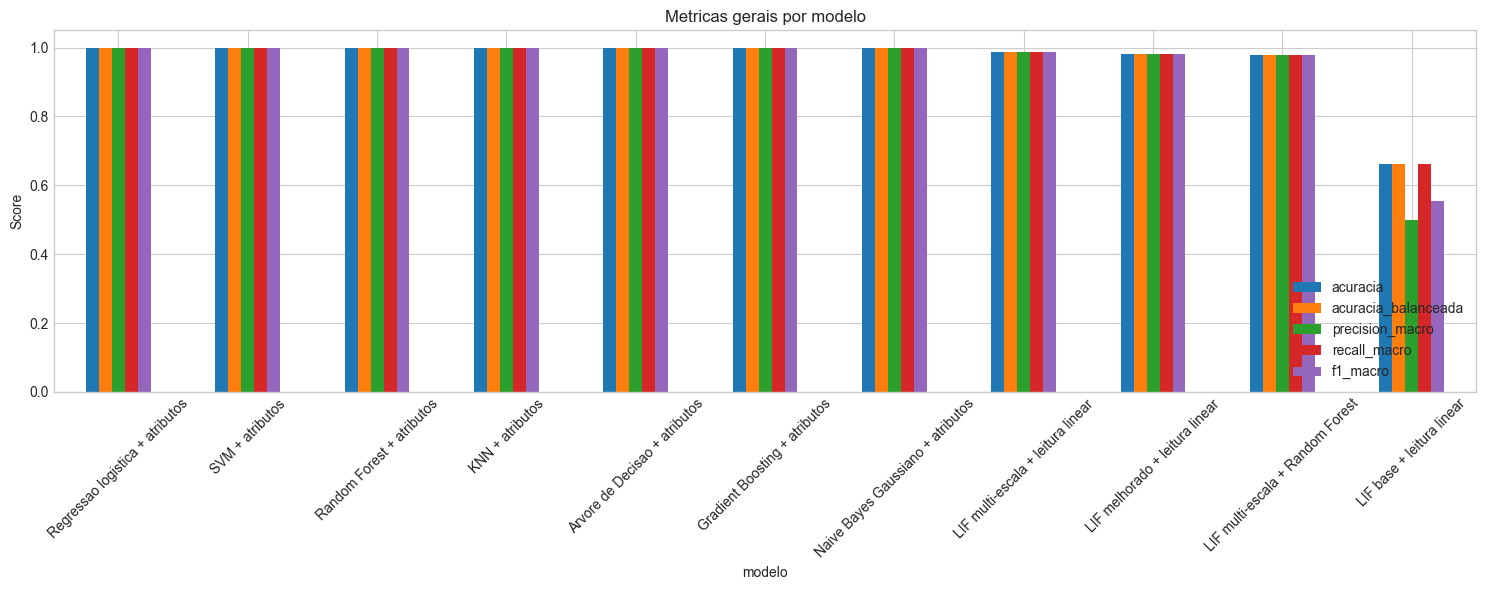

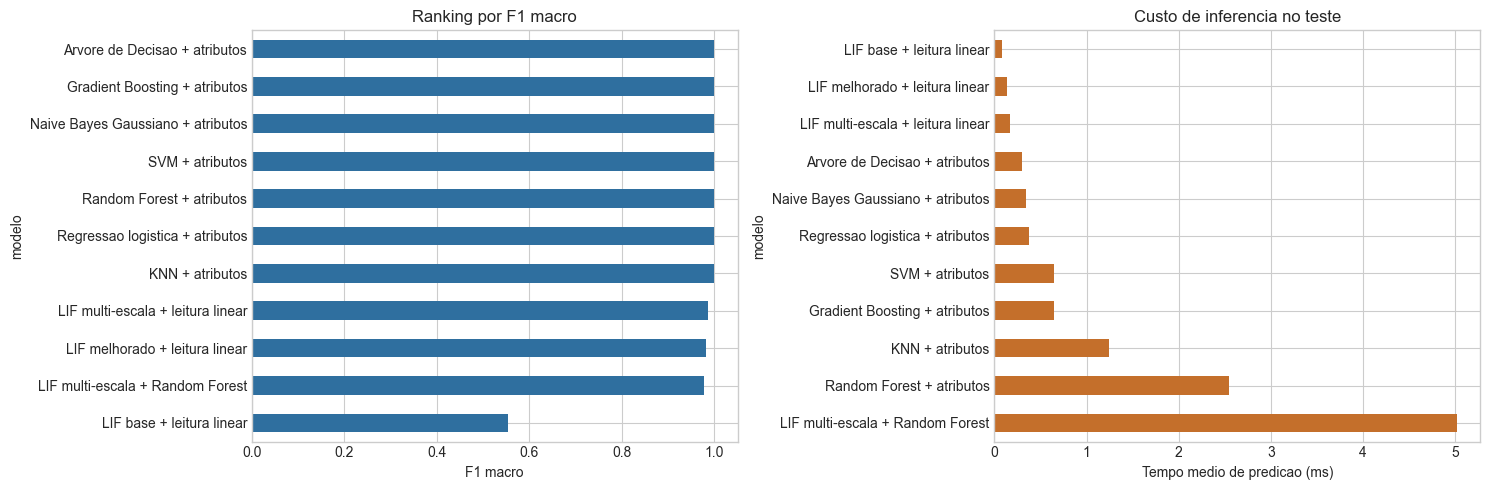

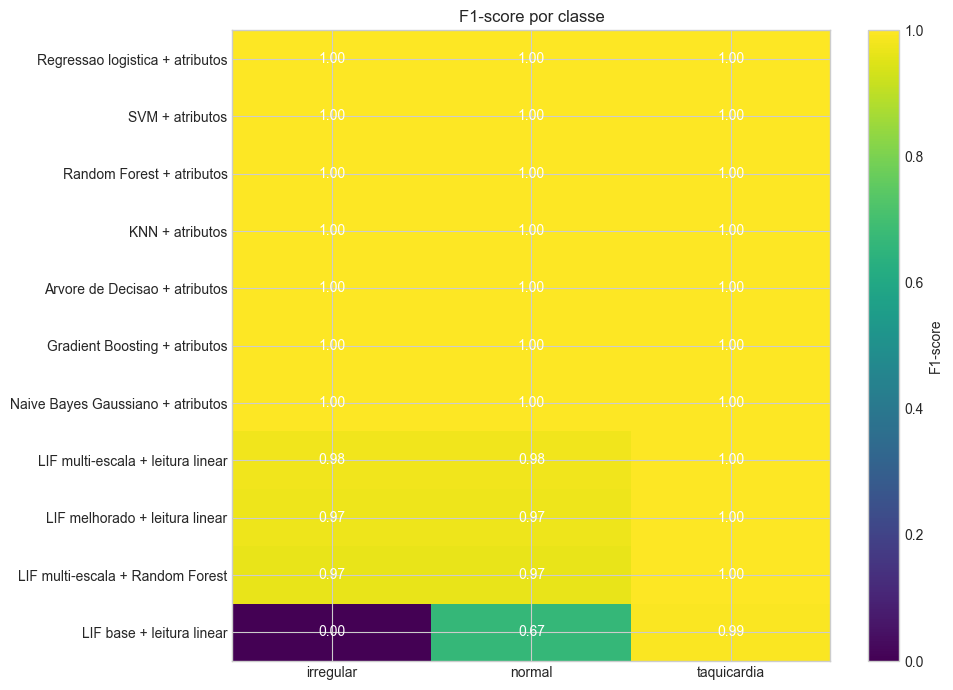

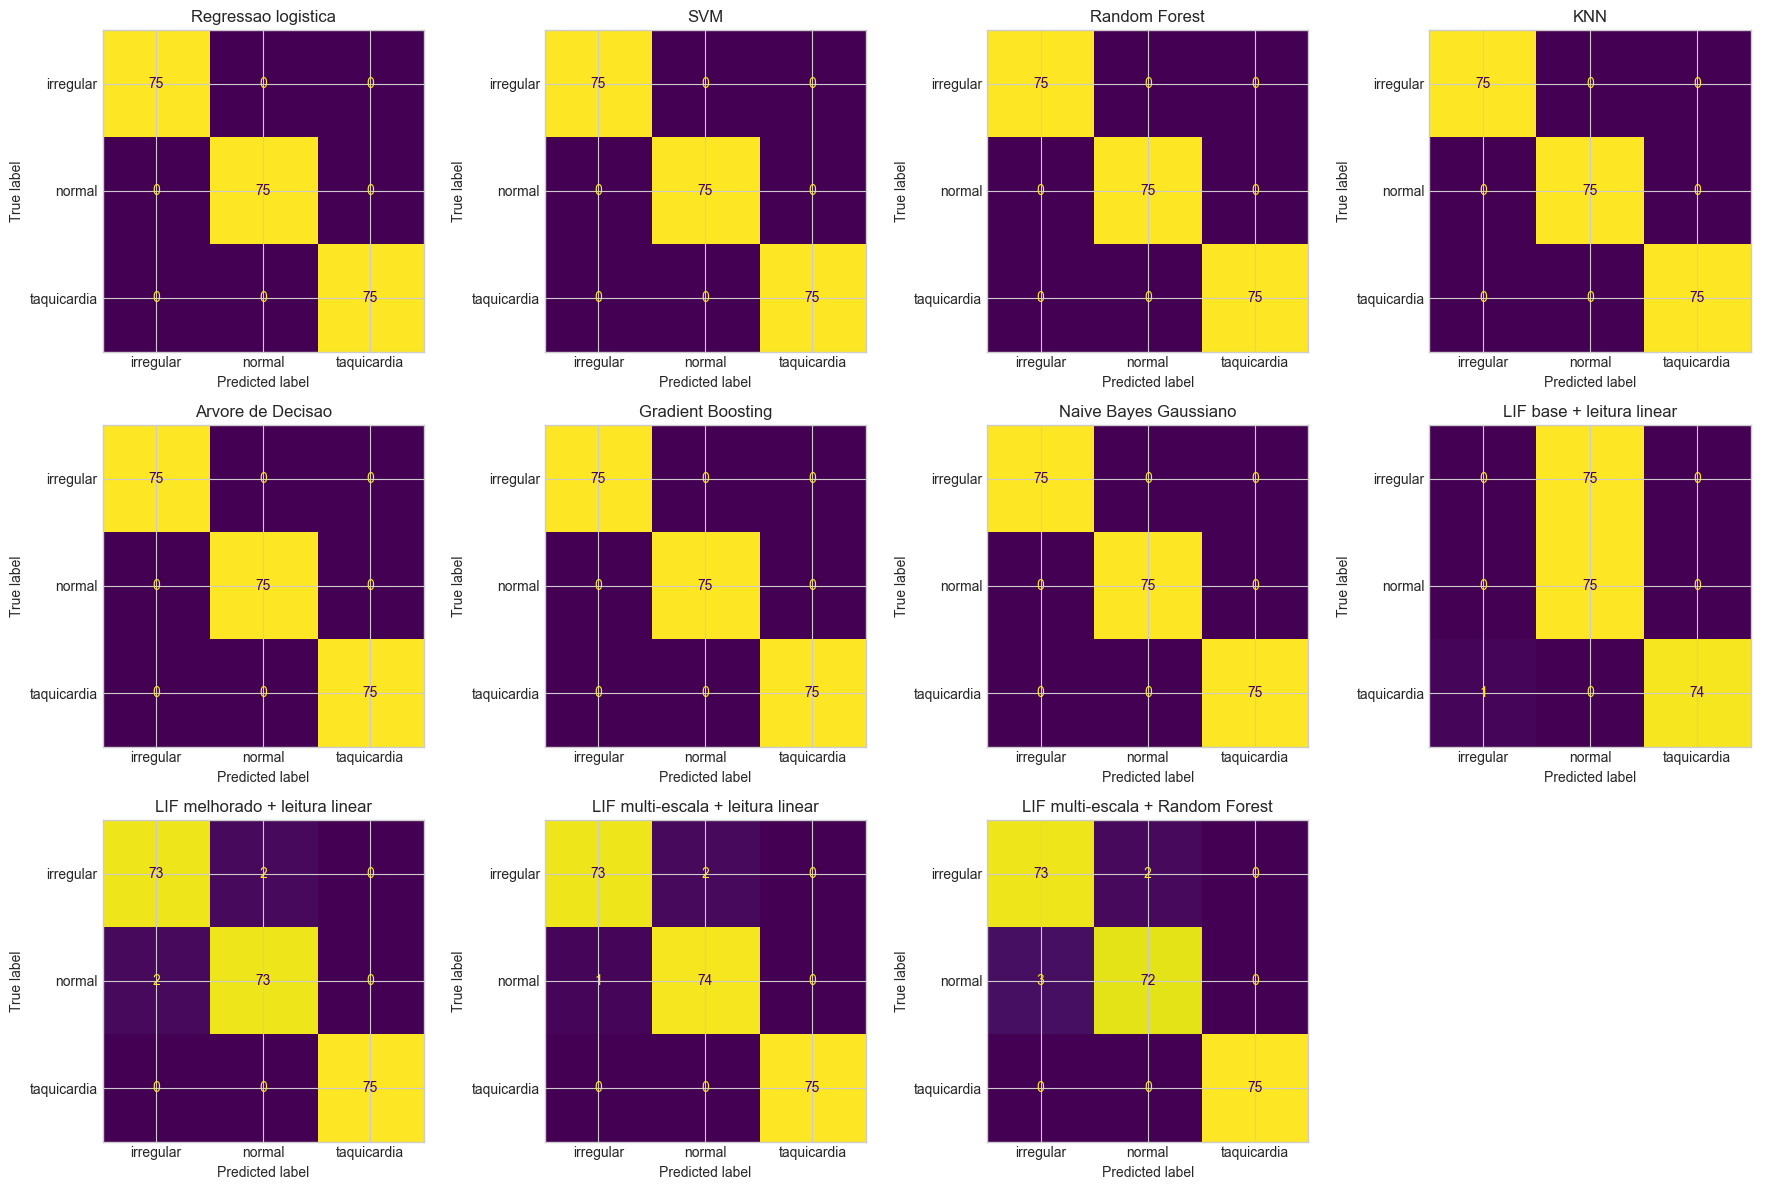

In [16]:
model_results = [
    ('Regressao logistica + atributos', traditional_model, X_test_features, traditional_pred, X_train_features.shape[1]),
    ('SVM + atributos', svm_model, X_test_features, svm_pred, X_train_features.shape[1]),
    ('Random Forest + atributos', rf_model, X_test_features, rf_pred, X_train_features.shape[1]),
    ('KNN + atributos', knn_model, X_test_features, knn_pred, X_train_features.shape[1]),
    ('Arvore de Decisao + atributos', dt_model, X_test_features, dt_pred, X_train_features.shape[1]),
    ('Gradient Boosting + atributos', gb_model, X_test_features, gb_pred, X_train_features.shape[1]),
    ('Naive Bayes Gaussiano + atributos', gnb_model, X_test_features, gnb_pred, X_train_features.shape[1]),
    ('LIF base + leitura linear', lif_model, X_lif_test, lif_pred, X_lif_train.shape[1]),
    ('LIF melhorado + leitura linear', lif_rich_model, X_lif_rich_test, lif_rich_pred, X_lif_rich_train.shape[1]),
    ('LIF multi-escala + leitura linear', lif_multiscale_model, X_lif_multiscale_test, lif_multiscale_pred, X_lif_multiscale_train.shape[1]),
    ('LIF multi-escala + Random Forest', lif_multiscale_rf_model, X_lif_multiscale_test, lif_multiscale_rf_pred, X_lif_multiscale_train.shape[1]),
]

class_labels = sorted(np.unique(y_test))

def prediction_time_ms(model, X, n_repeats=30):
    """Mede apenas o tempo medio de predicao sobre o conjunto de teste ja preparado."""
    start = perf_counter()
    for _ in range(n_repeats):
        model.predict(X)
    elapsed = perf_counter() - start
    return (elapsed / n_repeats) * 1000

summary_rows = []
per_class_rows = []
for name, model, X_eval, pred, n_features in model_results:
    report = classification_report(y_test, pred, output_dict=True, zero_division=0)
    summary_rows.append({
        'modelo': name,
        'acuracia': accuracy_score(y_test, pred),
        'acuracia_balanceada': balanced_accuracy_score(y_test, pred),
        'precision_macro': precision_score(y_test, pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_test, pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_test, pred, average='macro'),
        'f1_ponderado': f1_score(y_test, pred, average='weighted'),
        'numero_de_atributos': n_features,
        'tempo_predicao_ms': prediction_time_ms(model, X_eval),
    })

    for label in class_labels:
        per_class_rows.append({
            'modelo': name,
            'classe': label,
            'precision': report[label]['precision'],
            'recall': report[label]['recall'],
            'f1': report[label]['f1-score'],
        })

results = pd.DataFrame(summary_rows).sort_values('f1_macro', ascending=False).reset_index(drop=True)
per_class_results = pd.DataFrame(per_class_rows)

display(results)
display(per_class_results)

metric_columns = ['acuracia', 'acuracia_balanceada', 'precision_macro', 'recall_macro', 'f1_macro']
plot_data = results.set_index('modelo')[metric_columns]

fig, ax = plt.subplots(figsize=(15, 6))
plot_data.plot(kind='bar', ax=ax)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Metricas gerais por modelo')
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
results.sort_values('f1_macro').plot.barh(x='modelo', y='f1_macro', ax=axes[0], legend=False, color='#2f6f9f')
axes[0].set_xlim(0, 1.05)
axes[0].set_xlabel('F1 macro')
axes[0].set_title('Ranking por F1 macro')

results.sort_values('tempo_predicao_ms', ascending=False).plot.barh(
    x='modelo', y='tempo_predicao_ms', ax=axes[1], legend=False, color='#c46f2b'
)
axes[1].set_xlabel('Tempo medio de predicao (ms)')
axes[1].set_title('Custo de inferencia no teste')
plt.tight_layout()
plt.show()

f1_by_class = per_class_results.pivot(index='modelo', columns='classe', values='f1').loc[results['modelo']]
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(f1_by_class.values, aspect='auto', vmin=0, vmax=1, cmap='viridis')
ax.set_xticks(np.arange(len(f1_by_class.columns)))
ax.set_xticklabels(f1_by_class.columns)
ax.set_yticks(np.arange(len(f1_by_class.index)))
ax.set_yticklabels(f1_by_class.index)
ax.set_title('F1-score por classe')
for i in range(f1_by_class.shape[0]):
    for j in range(f1_by_class.shape[1]):
        ax.text(j, i, f'{f1_by_class.iloc[i, j]:.2f}', ha='center', va='center', color='white')
fig.colorbar(im, ax=ax, label='F1-score')
plt.tight_layout()
plt.show()

n_cols = 4
n_rows = int(np.ceil(len(model_results) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = np.array(axes).ravel()
for ax, (name, _, _, pred, _) in zip(axes, model_results):
    ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax, colorbar=False)
    ax.set_title(name.replace(' + atributos', ''))
for ax in axes[len(model_results):]:
    ax.axis('off')
plt.tight_layout()
plt.show()


## 5. Analise critica

- A regressao logistica continua sendo uma linha de base interpretavel, mas nao deve ser a unica referencia do experimento.
- SVM, Random Forest, KNN, Arvore de Decisao, Gradient Boosting e Naive Bayes ajudam a testar fronteiras lineares, nao lineares, baseadas em vizinhanca, arvores e probabilidades.
- O LIF base e propositalmente simples, mas fica limitado por normalizacao, poucos atributos de disparo e uma unica constante de tempo.
- As variacoes neuromorficas melhoram a comparacao ao usar escala definida pelo treino, atributos temporais mais ricos, populacoes multi-escala e leitura nao linear.
- Nesta base sintetica, a engenharia de atributos ainda pode favorecer os modelos tradicionais, entao a comparacao deve considerar tambem simplicidade, interpretabilidade e risco de overfitting.
- Em dados reais de saude, seria essencial validar por paciente, analisar falso negativo e usar metricas clinicas como sensibilidade e especificidade.

Conclusao: comparar varios classificadores tradicionais reduz a dependencia de uma unica regressao logistica. As variacoes LIF tornam a abordagem neuromorfica mais competitiva e mais justa, mas ainda precisam de calibracao e validacao rigorosa antes de uso pratico.
